#Problem definition
Forward transmission error ($TE_f$) can be written as a function
\begin{align*}
  𝑇𝐸_f\colon [0,360]&\times\mathbb{R}\times\mathbb{R} \longrightarrow \mathbb{R}\\
  (\theta_{out}&,\omega_{in}, T_{l})  \longmapsto y
\end{align*}
\
Thus, $TE_f$ can be represented across its entire frequency spectrum by means of the Fourier transform (FT). As most frequencies in the spectrum exhibit a low magnitude, we can focus on preserving just the most significant frequencies. Specifically, we adopt a simplified mathematical formulation for $TE_f$, defined as the sum of the main significant harmonics:
\begin{equation}
𝑇𝐸_{f,𝑚𝑜𝑑𝑒l}(\theta_{out},\omega_{in}, T_{l})  =\sum_{k\in P}𝐴_{f,𝑘} \cos(𝑘\theta_{out} + \phi_{f,𝑘})
\end{equation}
where $𝑃$ denotes the vector of selected harmonic orders, while $𝐴_{f,𝑘}$ and $\phi_{f,𝑘}$ represent the amplitude and phase shift of harmonic $𝑘$. To determine $𝑇𝐸_{f,𝑚𝑜𝑑𝑒l}$, we require the two vectors $𝐴_{f}=(𝐴_{f,k_1},\dots, 𝐴_{f,k_{|P|}})^T$ and $\phi_{f}=(\phi_{f,k_1},\dots, \phi_{f,k_{|P|}})^T$ (for any combination of $\omega_{in}$ and $T_{l}$).


Therefore, we formulate the task of forecasting $𝑇𝐸_{f,𝑚𝑜𝑑𝑒l}$ as a regression problem, where the aim is to predict two vectors $𝐴_{f},\phi_{f}\in \mathbb{R}^{|P|}$, as a function $f$ of a $2$-dimensional set of features:

\begin{align*}
  f\colon &\mathbb{R}\times\mathbb{R} \longrightarrow \mathbb{R}^{|P|}\times\mathbb{R}^{|P|}\\
  (&\omega_{in}, T_{l})  \longmapsto (𝐴_{f},\phi_{f})
\end{align*}







In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
import re
import matplotlib.pyplot as plt
import numpy as np
inputPath = '/content/drive/MyDrive/TestRig_ML/ML Transmisison Error/Instances'
%cd /content/drive/MyDrive/TestRig_ML/ML Transmisison Error/Code

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1PSyiQrxgDvR6gSFcISgaKHFES67dzy9r/TestRig_ML/ML Transmisison Error/Code


In [2]:
from instance_v2 import Instance 
from statistic import Statistics
from matplotlib import pyplot as plt
import pandas as pd

# Read all the instances and create pik files

In [4]:
inputPath = '../Instances/'
s = Statistics()
s.read_all(inputPath)

[0, 0.026870956879920384, 0.21812655455393168, 1.7772557820513828, 1.6790398587673754, 2.5745489875523115, -0.7032765213461902]
[0, 0.03010240367988822, 0.300751416370157, 2.4297347016351942, -1.8048133338900811, 2.6799400071425765, -0.862241581497156]
[0, 0.03011336983016958, 0.3084157557573089, 2.475006484046569, -1.8197679179728046, 2.6049721543001194, -0.4038362904552998]
[0, 0.027383297563038086, 0.2045832035609788, 1.7820185594363218, -1.4236912115889335, 2.6140984927768445, -0.8453557675962368]
[0, 0.028966477748425895, 0.15329356025044047, 1.6616991809675055, 1.6170584531863221, 2.3776919067092748, -0.12922433624771718]
[0, 0.028560179843807647, 0.14044001772705106, 1.5735916068779687, -1.7963945020164418, 2.486116785056469, -0.35891512547706533]
[0, 0.030153320549619427, 0.10978107678537569, 1.7058785291056098, -1.8196439045520512, 2.5343314864825714, -0.7709998792177062]
[0, 0.027480301934906172, 0.1776791033947821, 1.9570357876210362, -1.5969149223877708, 2.651673944504393, 

# Create csv for prediction

In [5]:
df_tot = s.genDfWithAmplEPhase()
df_tot.to_csv('dataFrame_prediction_v1.csv',sep=';',decimal=',')

# Read csv 

In [6]:
dfInput = pd.read_csv('dataFrame_prediction_v1.csv',sep=';',decimal=',',index_col=[0])
files = os.listdir('../Instances')

dfOutTot = pd.DataFrame()
colsToPredict = ['fft_y_Fw_filtered_ampl_','fft_y_Fw_filtered_phase_']

# Predict with Polyfunc
For each combination of $\omega_{in}$ and $T_{l}$, Polyfunc evaluates the  $k$-th element in $𝐴_{f}$ and in $\phi_{f}$ by means of the following following third order polynomial surfaces:
$$ A_{f,k}=\sum_{m=0}^{3}\sum_{n=0}^{3-m}p_{m,n}\omega_{in}^mT_{l}^n$$

$$ \phi_{f,k}=\sum_{m=0}^{3}\sum_{n=0}^{3-m}q_{m,n}\omega_{in}^mT_{l}^n$$


where $p_{m,n}$ and $q_{m,n}$ are the fitting coefficients.

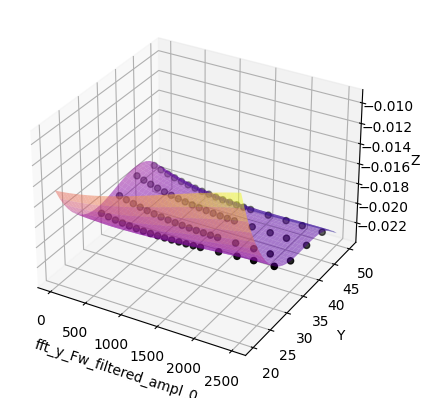

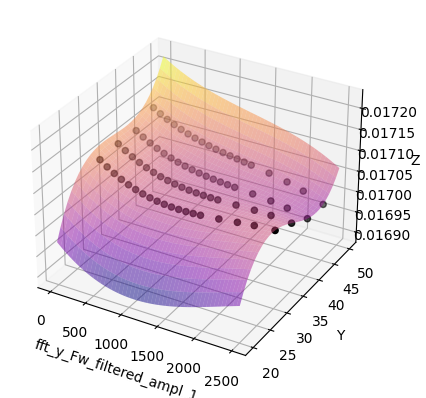

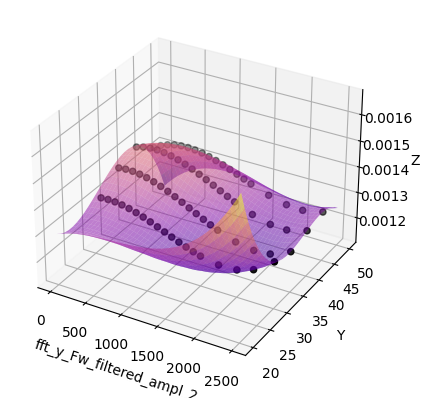

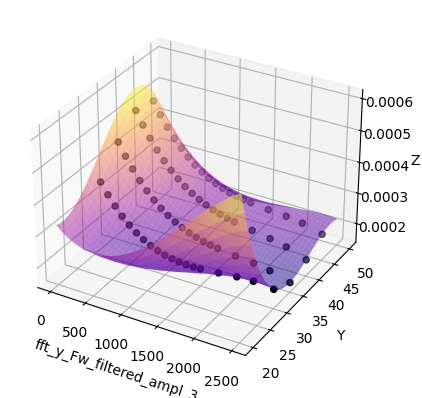

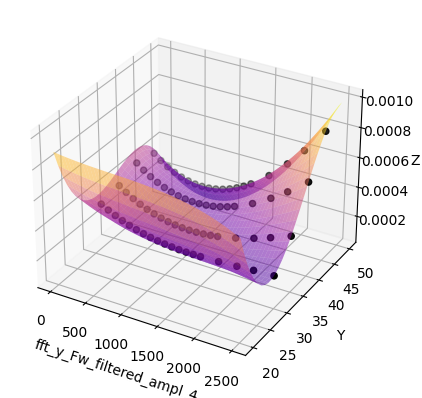

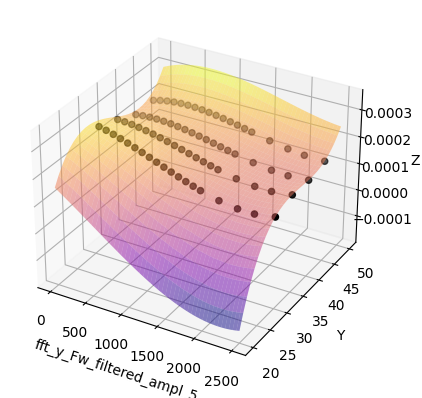

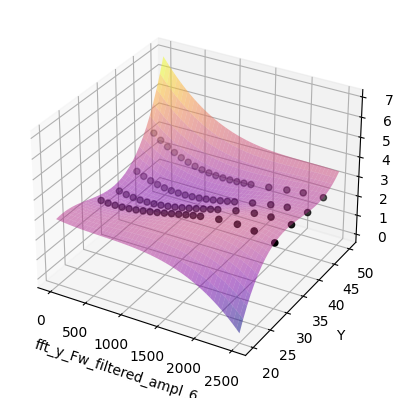

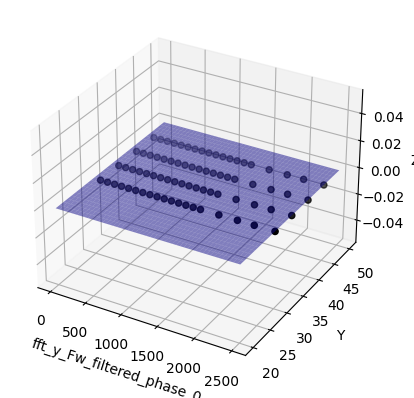

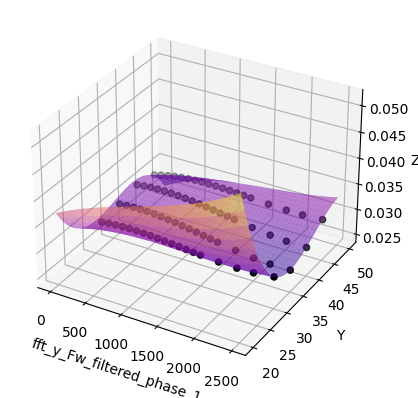

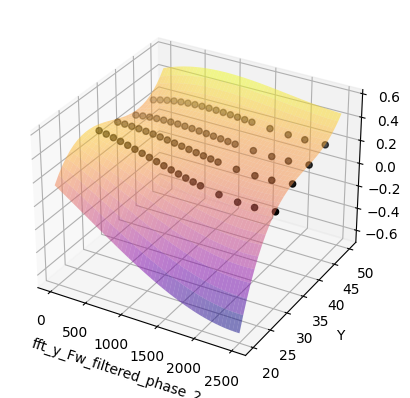

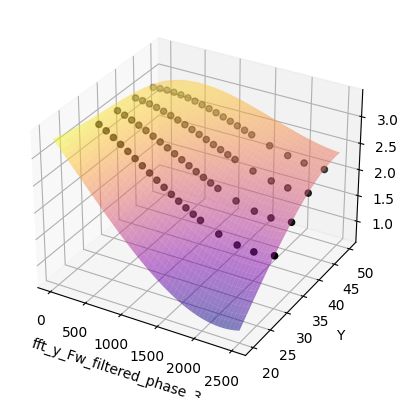

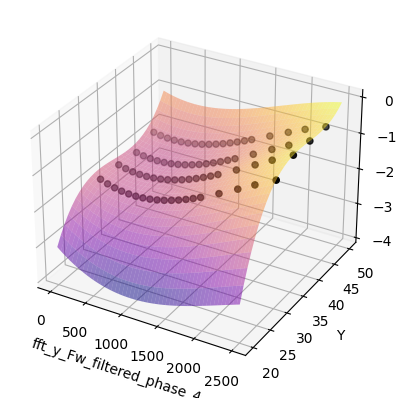

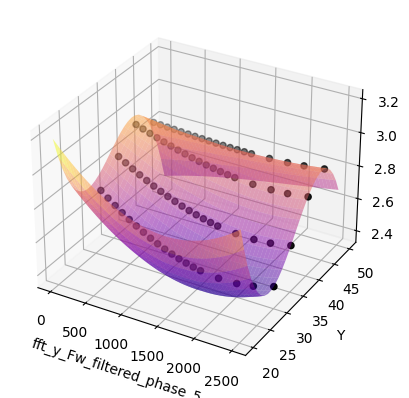

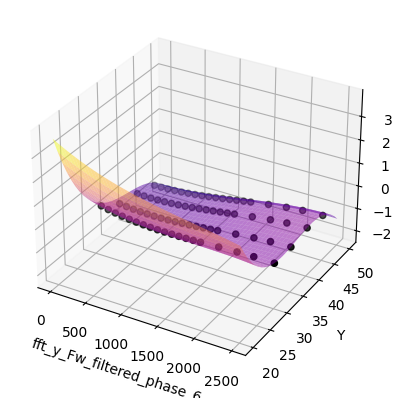

In [7]:
from predictorPolyFunc import PolyFunc
####    PREDICTION USING POLYFIT    #####
dfOutTot = pd.DataFrame()
for col in colsToPredict:
    for i in range(7):
        polyModel = PolyFunc('polyfit_v2',col+str(i))
        dfOut,params_opt = polyModel.predictorPolyFunc(dfInput,files)
        #dfOut,params_opt = polyModel.predictorPolyFunc_NoTest(dfInput,files,'500.0rpm30.0deg0Torque.csv')
        
        polyModel.plotGraph(dfOut,params_opt)
        if dfOutTot.empty:
            dfOutTot=dfOut
        else:
            dfOutTot = dfOutTot.merge(dfOut,on=['name'])

dfOutTot.to_csv('output_prediction/dfOutTot_prediction_polyfit_v1.csv', sep=';', decimal=',')
#######################################

In [9]:
from predictorPolyFunc import PolyFunc
####    PREDICTION USING POLYFIT    #####
dfOutTot = pd.DataFrame()
for col in colsToPredict:
    for i in range(7):
        polyModel = PolyFunc('polyfit_v2',col+str(i))
        #dfOut,params_opt = polyModel.predictorPolyFunc(dfInput,files)
        #dfOut,params_opt = polyModel.predictorPolyFunc_NoTest(dfInput,files,'500.0rpm30.0deg0Torque.csv')
        dfOut = polyModel.predictorPolyFunc_leaveOneOut(dfInput,files)
        #polyModel.plotGraph(dfOut,params_opt)
        if dfOutTot.empty:
            dfOutTot=dfOut
        else:
            dfOutTot = dfOutTot.merge(dfOut,on=['name'])

dfOutTot.to_csv('output_prediction/dfOutTot_prediction_polyfit_v3.csv', sep=';', decimal=',')
#######################################

# Predict with ML Models
To improve the accuracy of $𝑇𝐸_{f,𝑚𝑜𝑑𝑒l}$ prediction, we aim at exploiting a data-driven approach based on ML algorithms. 
Using a provided dataset $\mathcal{D}$, we train different ML models belonging to the following classes: 

*   Linear Regression (LR)
*   Support Vector Regression (SVR)
*   Gradient Boosting Regression (GBR)
*   Random Forest Regression (RF)

Dataset $\mathcal{D}$ is composed of 74 samples.
The models are fit on $\mathcal{D}_{train}$ composed of 73 samples and test on the remaining sample.



In [10]:
from predictorML import MLPipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

####    PREDICTION USING ML MODEL    #####
dfOutTot = pd.DataFrame()
for col in colsToPredict: #per le colonne ampiezza e fase
    for i in range(7): #per ogniuna delle 7 frequenze
        #mlModel = MLAutoMLRegressor('auto_ml',col+str(i))
        mlModel = MLPipeline(SVR(),'svr_pipeline',col+str(i))
        params_small= {'model__kernel': ['rbf'],
                              'model__C': [ 30, 50, 100, 250],
                              'model__epsilon': [0.1, 0.5, 1],
                              'model__max_iter':[15000]}
        params_complete = {'model__kernel': ['linear','rbf','sigmoid'],
                              'model__C': [1.5, 5, 10, 30, 50, 100, 150, 200, 250],
                              'model__epsilon': [0.1, 0.5, 1, 5, 9, 10, 13],
                              'model__max_iter':[100, 500, 1500, 15000]}
        #mlModel.gridSearch(params_small)

        #dfOut = mlModel.predictorAutoML_leaveOneOut(dfInput,files)
        dfOut = mlModel.predictorML_leaveOneOut(dfInput,files)
        #dfOut = mlModel.predictorML_singleModel_leaveOneOut(dfInput,files)
        if dfOutTot.empty:
            dfOutTot=dfOut
        else:
            dfOutTot = dfOutTot.merge(dfOut,on=['name'])
dfOutTot.to_csv('output_prediction/dfOutTot_prediction_svr_v1.csv', sep=';', decimal=',')

NameError: ignored

# Evaluate prediction
Performance evaluations of the obtained models were done by measuring their quality using five statistical indicators: *mean square error* (MSE), *root mean square error* (RMSE), *mean absolute error* (MAE), and *mean absolute percentage error* (MAPE). More precisely:
\begin{equation*}
\begin{split}
MSE&={\frac {1}{m}}\sum _{i=1}^{m}\left(y_{i}-{\widetilde{y_{i}}}\right)^{2}\\
RMSE&={\sqrt {\frac {1}{m}\sum _{i=1}^{m}({{y}}_{i}-\widetilde{y_{i}})^{2}}}\\
MAE&={\frac {1}{m}\sum _{i=1}^{m}|{{y}}_{i}-\widetilde{y_{i}}|}\\
MAPE&={\frac {1}{m}\sum _{i=1}^{m}\left|\dfrac{{{y}}_{i}-\widetilde{y_{i}}}{{{y}}_{i}}\right|}  
\end{split}
\end{equation*}

[0, 0.028069641008736653, 0.3386941365012594, 2.7912430433563307, -2.0280203403046873, 2.5702150684450253, -0.4829479388437737]
reale vs fft, MAPE: 0.07218266775631188


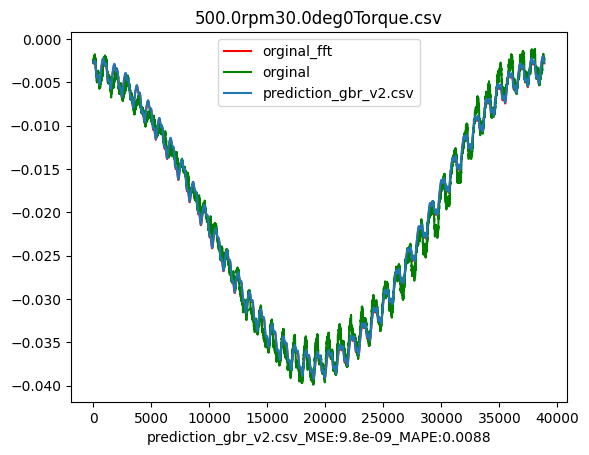

In [ ]:
error_tot = {'instance':[],'method':[],'mode':[],'MSE':[], 'RMSE':[],'MAE':[],'MAPE':[]}
i = Instance.read(inputPath+'500.0rpm30.0deg0Torque.csv')
f = 'output_prediction/dfOutTot_prediction_gbr_v2.csv'
mode = 'fft'
mse, rmse,mae, mape = i.predicted_TE_Fw(f,mode)
error_tot['instance'].append(i.name)
error_tot['method'].append(f.split('dfOutTot_')[1])
error_tot['mode'].append(mode)
error_tot['MSE'].append(round(mse,5))
error_tot['RMSE'].append(round(rmse,5))
error_tot['MAE'].append(round(mae,5))
error_tot['MAPE'].append(str(round(mape*100,2))+'%')

[0, 0.028069641008736653, 0.3386941365012594, 2.7912430433563307, -2.0280203403046873, 2.5702150684450253, -0.4829479388437737]
reale vs fft, MAPE: 0.07218266775631188


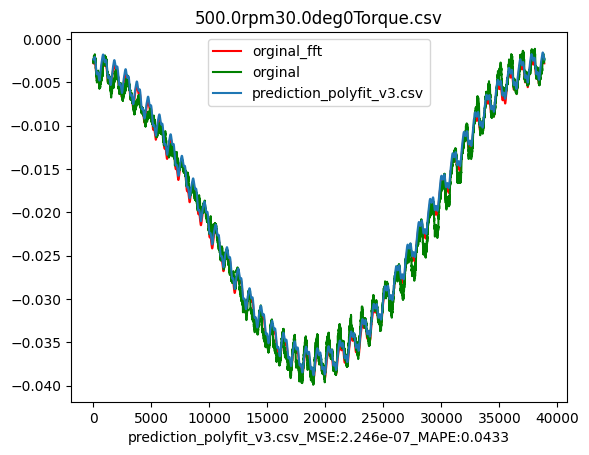

In [ ]:
i = Instance.read(inputPath+'500.0rpm30.0deg0Torque.csv')
f = 'output_prediction/dfOutTot_prediction_polyfit_v3.csv'
mode = 'fft'
mse, rmse,mae, mape = i.predicted_TE_Fw(f,mode)
error_tot['instance'].append(i.name)
error_tot['method'].append(f.split('dfOutTot_')[1])
error_tot['mode'].append(mode)
error_tot['MSE'].append(round(mse,5))
error_tot['RMSE'].append(round(rmse,5))
error_tot['MAE'].append(round(mae,5))
error_tot['MAPE'].append(str(round(mape*100,2))+'%')

[0, 0.026702431927320965, 0.33427010514503974, 2.9833753346989584, -2.049247696063283, 2.862703145710038, -0.9278426154718425]
reale vs fft, MAPE: 0.6366933365470872


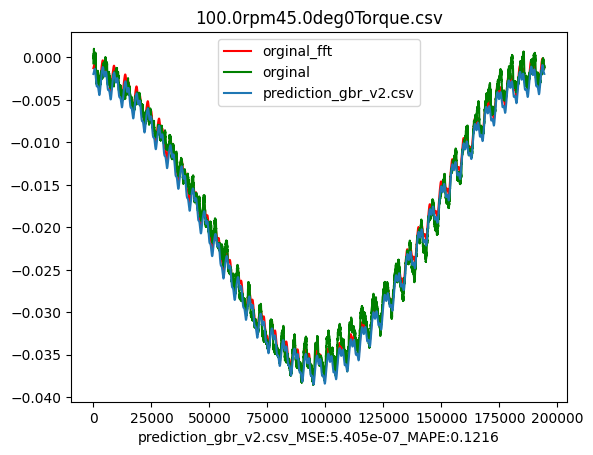

In [ ]:
i = Instance.read(inputPath+'100.0rpm45.0deg0Torque.csv')
f = 'output_prediction/dfOutTot_prediction_gbr_v2.csv'
mode = 'fft'
mse, rmse,mae, mape = i.predicted_TE_Fw(f,mode)
error_tot['instance'].append(i.name)
error_tot['method'].append(f.split('dfOutTot_')[1])
error_tot['mode'].append(mode)
error_tot['MSE'].append(round(mse,5))
error_tot['RMSE'].append(round(rmse,5))
error_tot['MAE'].append(round(mae,5))
error_tot['MAPE'].append(str(round(mape*100,2))+'%')

[0, 0.026702431927320965, 0.33427010514503974, 2.9833753346989584, -2.049247696063283, 2.862703145710038, -0.9278426154718425]
reale vs fft, MAPE: 0.6366933365470872


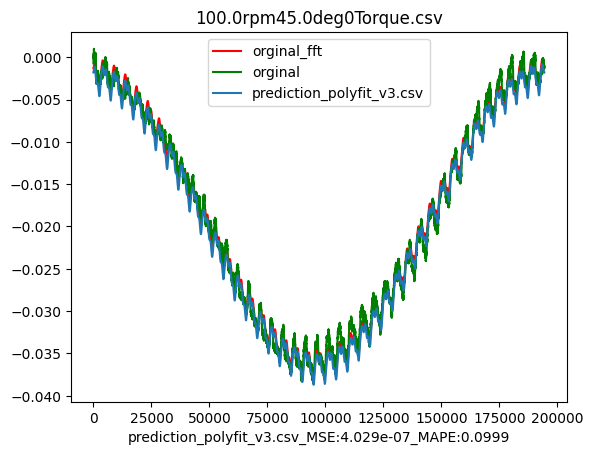

In [ ]:
i = Instance.read(inputPath+'100.0rpm45.0deg0Torque.csv')
f = 'output_prediction/dfOutTot_prediction_polyfit_v3.csv'
mode = 'fft'
mse, rmse,mae, mape = i.predicted_TE_Fw(f,mode)
error_tot['instance'].append(i.name)
error_tot['method'].append(f.split('dfOutTot_')[1])
error_tot['mode'].append(mode)
error_tot['MSE'].append(round(mse,5))
error_tot['RMSE'].append(round(rmse,5))
error_tot['MAE'].append(round(mae,5))
error_tot['MAPE'].append(str(round(mape*100,2))+'%')

[0, 0.028439435109356707, 0.22975838776225474, 2.182992595750166, 1.7973878279095183, 2.7986290033846144, -0.6082642880056066]
reale vs fft, MAPE: 2.2680431780398655


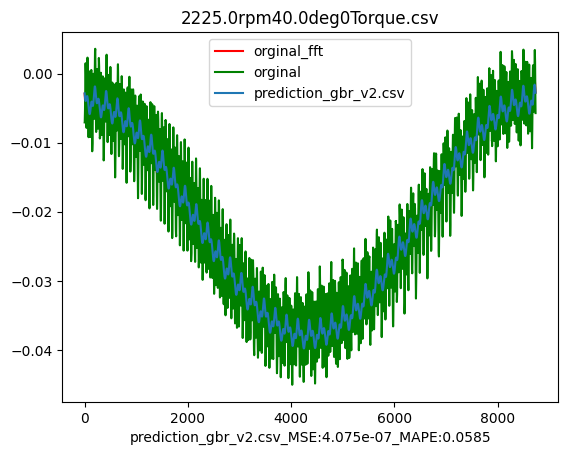

In [ ]:
i = Instance.read(inputPath+'2225.0rpm40.0deg0Torque.csv')
f = 'output_prediction/dfOutTot_prediction_gbr_v2.csv'
mode = 'fft'
mse, rmse,mae, mape = i.predicted_TE_Fw(f,mode)
error_tot['instance'].append(i.name)
error_tot['method'].append(f.split('dfOutTot_')[1])
error_tot['mode'].append(mode)
error_tot['MSE'].append(round(mse,5))
error_tot['RMSE'].append(round(rmse,5))
error_tot['MAE'].append(round(mae,5))
error_tot['MAPE'].append(str(round(mape*100,2))+'%')

[0, 0.028439435109356707, 0.22975838776225474, 2.182992595750166, 1.7973878279095183, 2.7986290033846144, -0.6082642880056066]
reale vs fft, MAPE: 2.2680431780398655


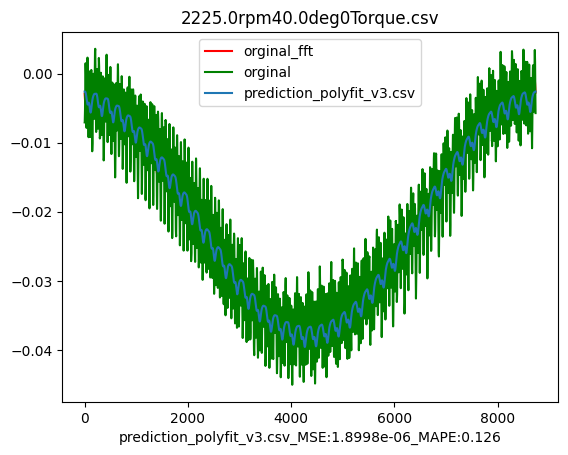

In [ ]:
i = Instance.read(inputPath+'2225.0rpm40.0deg0Torque.csv')
f = 'output_prediction/dfOutTot_prediction_polyfit_v3.csv'
mode = 'fft'
mse, rmse,mae, mape = i.predicted_TE_Fw(f,mode)
error_tot['instance'].append(i.name)
error_tot['method'].append(f.split('dfOutTot_')[1])
error_tot['mode'].append(mode)
error_tot['MSE'].append(round(mse,5))
error_tot['RMSE'].append(round(rmse,5))
error_tot['MAE'].append(round(mae,5))
error_tot['MAPE'].append(str(round(mape*100,2))+'%')

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
pd.DataFrame(error_tot)

,instance,method,mode,MSE,RMSE,MAE,MAPE
0,500.0rpm30.0deg0Torque.csv,prediction_gbr_v2.csv,fft,0.0,0.00010,0.00010,0.88%
1,500.0rpm30.0deg0Torque.csv,prediction_polyfit_v3.csv,fft,0.0,0.00047,0.00047,4.33%
2,100.0rpm45.0deg0Torque.csv,prediction_gbr_v2.csv,fft,0.0,0.00074,0.00073,12.16%
3,100.0rpm45.0deg0Torque.csv,prediction_polyfit_v3.csv,fft,0.0,0.00063,0.00061,9.99%
4,2225.0rpm40.0deg0Torque.csv,prediction_gbr_v2.csv,fft,0.0,0.00064,0.00054,5.85%
5,2225.0rpm40.0deg0Torque.csv,prediction_polyfit_v3.csv,fft,0.0,0.00138,0.00123,12.6%
